## KEYWORDS 🔬 
This is a notebook that allows you to use the already existing data base (the csv files and xlsx  fils)
If you have aredy extracted the fils you cas scroll or use the hyperlinks to go directly to the reload or surch section. 
⚠️ links may not work, just scroll down to the marked sections.

# 🔬 Research Paper Search Tool

### Quick Navigation
| | |
|---|---|
| 📂 **Already have the files?** | [Click here to reload data only](#reload) |
| 🔍 **Ready to search?** | [Click here to go to search](#search) |
| 📊 **View results?** | [Click here to go to results](#results) |
⚠️ **JupyterLab users:** links may not work, just scroll down to the marked sections.

## This is a section where i show you how the keywords are extracted, and some modifications that need to be done to obtain the final file (data base) that is called Research_Database.xlsx
Once you have the fils, you do not need to re run this section.
You can modify the fils names but be careful to modify them everywhere.

Here i import the CSV that contains the abstracts from PUB MED 

In [3]:
import pandas as pd
DF_commune = pd.read_csv("Ready_for_now_with_abstracts.csv", encoding="latin-1")
DF_commune

FileNotFoundError: [Errno 2] No such file or directory: 'Ready_for_now_with_abstracts.csv'

This is the code that extracts the keywords from this csv

In [2]:
from keybert import KeyBERT

# Load the model
kw_model = KeyBERT()

def extract_keywords(abstract, n=5):# Skip empty/NaN/not found values
    if pd.isna(abstract):
        return []
    # Skip rows with no abstract
    if abstract in ["Not found", "N/A"] or "Error" in str(abstract):
        return []
    
    keywords = kw_model.extract_keywords(
        abstract,
        keyphrase_ngram_range=(1, 2),  # single words and 2-word phrases
        stop_words='english',           # ignore common words like "the", "and"
        top_n=n                         # number of keywords to extract
    )
    return [kw[0] for kw in keywords]  # return just the words, not the scores

# Apply to all abstracts
print("Extracting keywords...")
DF_commune["Keywords"] = DF_commune["Abstract PUB MED"].apply(extract_keywords)
print("Done!")

# Preview results
print(DF_commune[["GSE", "Keywords"]].head(10))

Extracting keywords...
Done!
         GSE                                           Keywords
0  GSE315393                                                 []
1  GSE329198                                                 []
2  GSE305396                                                 []
3  GSE305395                                                 []
4  GSE305394                                                 []
5  GSE305225  [h3k9me3 seeds, seed dormancy, seeds arabidops...
6  GSE296178  [androgen receptor, prostate lineage, hormonal...
7  GSE289313  [pathogenesis psoriasis, kynureninase psoriasi...
8  GSE315959  [foxa1 binding, foxa1 pioneering, androgen rec...
9  GSE241255  a chromatin, lncrna chromatin, methyltransf...


Here i have a visualisation of the top 20 keywors in this CSV

In [ ]:
import matplotlib.pyplot as plt
from collections import Counter

# Flatten all keywords into one list
all_keywords = [kw for keywords in DF_commune["Keywords"] for kw in keywords]

# Count frequencies
keyword_counts = Counter(all_keywords)

# Get top 20
top_20 = keyword_counts.most_common(20)
words = [item[0] for item in top_20]
counts = [item[1] for item in top_20]

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(words[::-1], counts[::-1], color="steelblue")

# Add count labels on bars
for bar, count in zip(bars, counts[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(count), va='center', fontsize=10)

ax.set_xlabel("Frequency", fontsize=12)
ax.set_title("Top 20 Keywords from PubMed Abstracts", fontsize=14)
plt.tight_layout()
plt.show()

Here is the same process but with the CSV file that contains the GEO abstracts

loading the file

In [4]:
DF_commune2 = pd.read_csv("GEO_GSE_summary_corrected.csv", encoding="latin-1")
DF_commune2

,GSE,Samples,Title,Design_GSE,Summary_GSE,Title_GSE
0,GSE315959,51,Dissecting FOXA1 pioneering function by acute ...,NaN,Pioneer factors control transcription by openi...,Dissecting FOXA1 pioneering function by acute ...
1,GSE241255,4,Chromatin immunoprecipitation DNA sequencing (...,NaN,Purpose: Zinc Finger MIZ-Type Containing 1 (Zm...,Chromatin immunoprecipitation DNA sequencing (...
2,GSE301368,10,Acute hormonal signaling-induced 3D chromatin ...,NaN,Recent molecular advancements have revolutioni...,Acute hormonal signaling-induced 3D chromatin ...
3,GSE301366,24,Acute hormonal signaling-induced 3D chromatin ...,NaN,Recent molecular advancements have revolutioni...,Acute hormonal signaling-induced 3D chromatin ...
4,GSE261412,24,Acute hormonal signaling-induced 3D chromatin ...,NaN,Î²3-adrenergic receptor (Î²3-AR) hormonal sign...,Acute hormonal signaling-induced 3D chromatin ...
...,...,...,...,...,...,...
786,GSM2698833,0,HIF-1a ChIP-seq,NaN,This SuperSeries is composed of the SubSeries ...,Open Chromatin and HIF-binding in renal tubula...
787,GSM1010729,0,HudsonAlpha_ChipSeq_GM12878_MTA3_(SC-81325)_v0...,NaN,Eukaryotic chromosomes replicate in a temporal...,DNA replication-timing boundaries separate sta...
788,GSM730632,0,"Runx1+/VE-cadherin-/CD41+, ChIP-seq",NaN,This SuperSeries is composed of the SubSeries ...,The transcriptional program controlled by Runx...
789,GSM730631,0,"Runx1+/VE-cadherin+/CD41-, ChIP-seq",NaN,This SuperSeries is composed of the SubSeries ...,The transcriptional program controlled by Runx...


extracting keywords

In [5]:
from keybert import KeyBERT
import pandas as pd

kw_model = KeyBERT()

def extract_keywords(text, n=5):
    if pd.isna(text):
        return []
    if text in ["Not found", "N/A"] or "Error" in str(text):
        return []
    keywords = kw_model.extract_keywords(
        text,
        keyphrase_ngram_range=(1, 2),
        stop_words='english',
        top_n=n
    )
    return [kw[0] for kw in keywords]

print("Extracting keywords...")
DF_commune2["Keywords"] = DF_commune2["Summary_GSE"].apply(extract_keywords)
print("Done!")
print(DF_commune2[["GSE", "Keywords"]].head())

Extracting keywords...
Done!
         GSE                                           Keywords
0  GSE315959  [genes foxa1, foxa1 binding, foxa1 pioneering,...
1  GSE241255  [sequencing zmiz1, zmiz1 associated, containin...
2  GSE301368  [adipocytes, brown adipocytes, receptor î²3, a...
3  GSE301366  [adipocytes, brown adipocytes, receptor î²3, a...
4  GSE261412  [adipocytes implications, 3d genome, receptor ...


visualisation of the top 20 words in this CSV

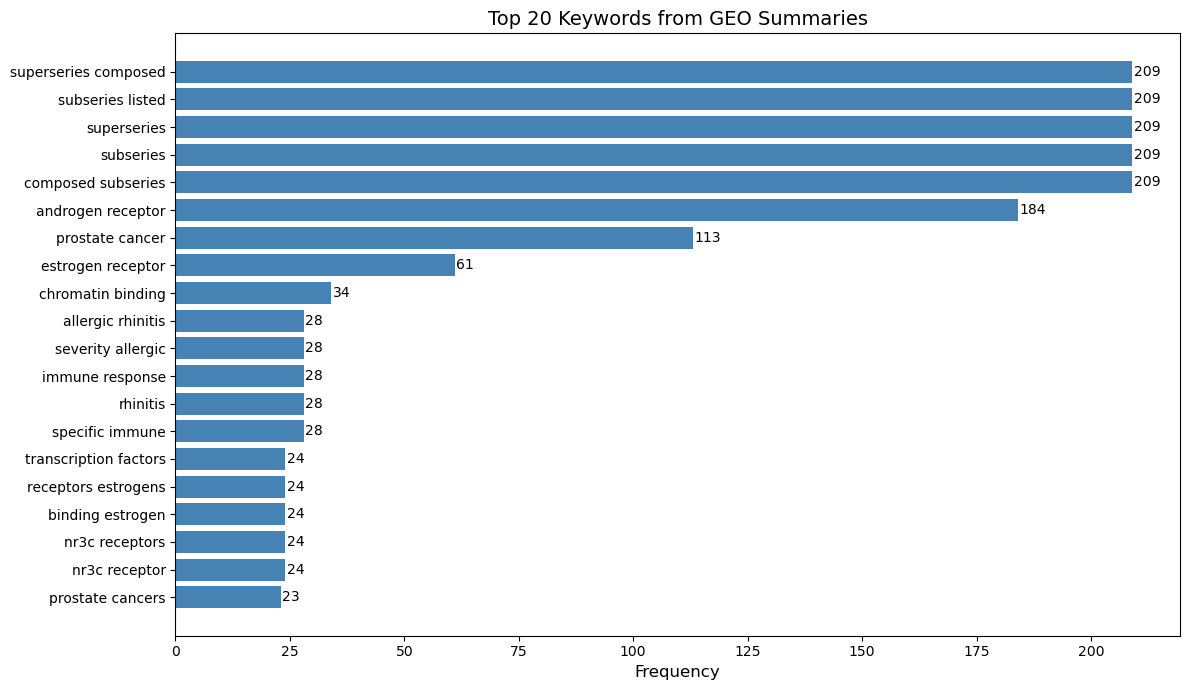

In [6]:
from collections import Counter
import matplotlib.pyplot as plt

# Flatten all keywords into one list
all_keywords2 = [kw for keywords in DF_commune2["Keywords"] for kw in keywords]

# Count frequencies
keyword_counts2 = Counter(all_keywords2)

# Get top 20
top_20_2 = keyword_counts2.most_common(20)
words2 = [item[0] for item in top_20_2]
counts2 = [item[1] for item in top_20_2]

# Plot
fig, ax = plt.subplots(figsize=(12, 7))
bars = ax.barh(words2[::-1], counts2[::-1], color="steelblue")

# Add count labels on bars
for bar, count in zip(bars, counts2[::-1]):
    ax.text(bar.get_width() + 0.3, bar.get_y() + bar.get_height()/2,
            str(count), va='center', fontsize=10)

ax.set_xlabel("Frequency", fontsize=12)
ax.set_title("Top 20 Keywords from GEO Summaries", fontsize=14)
plt.tight_layout()
plt.show()

## Here is the second part where i make the xlsx with the two CSVs containg the PUB MED and GEO abstracts

In [7]:
with pd.ExcelWriter("Research_Database.xlsx", engine="openpyxl") as writer:
    DF_commune.to_excel(writer, sheet_name="PubMed Abstracts", index=False)
    DF_commune2.to_excel(writer, sheet_name="GEO Summaries", index=False)

print("Saved to Research_Database.xlsx!")

Saved to Research_Database.xlsx!


Here i am adding PMID (id for PUB MED) extracted by my lab partner. and all of this is intagreted in one xlsx file Research_Database.xlsx

In [5]:
import pandas as pd
from openpyxl import load_workbook
from openpyxl.styles import Font, PatternFill, Alignment
from openpyxl.utils import get_column_letter

# Load existing sheets
df_pubmed = pd.read_excel("Research_Database.xlsx", sheet_name="PubMed Abstracts")
df_geo = pd.read_excel("Research_Database.xlsx", sheet_name="GEO Summaries")

# Build index dataframe
df_pubmed["Sheet"] = "PubMed Abstracts"
df_geo["Sheet"] = "GEO Summaries"

# Create index with key columns only
index_rows = []

for i, row in df_pubmed.iterrows():
    index_rows.append({
        "GSE": row["GSE"],
        "Title": row["Title"],
        "Source": "PubMed Abstracts",
        "Publication Date": row.get("Publication_Date", ""),
        "Keywords": str(row.get("Keywords", "")),
        "Row in Sheet": i + 2  # +2 for header and 0-index
    })

for i, row in df_geo.iterrows():
    index_rows.append({
        "GSE": row["GSE"],
        "Title": row["Title"],
        "Source": "GEO Summaries",
        "Publication Date": "",
        "Keywords": str(row.get("Keywords", "")),
        "Row in Sheet": i + 2
    })

df_index = pd.DataFrame(index_rows)

# Save all sheets
with pd.ExcelWriter("Research_Database.xlsx", engine="openpyxl") as writer:
    df_index.to_excel(writer, sheet_name="INDEX", index=False)
    df_pubmed.to_excel(writer, sheet_name="PubMed Abstracts", index=False)
    df_geo.to_excel(writer, sheet_name="GEO Summaries", index=False)

    # Now add hyperlinks and formatting to the index sheet
    wb = writer.book
    ws_index = wb["INDEX"]

    # Header styling
    header_fill = PatternFill(start_color="1F4E79", end_color="1F4E79", fill_type="solid")
    header_font = Font(color="FFFFFF", bold=True)
    for cell in ws_index[1]:
        cell.fill = header_fill
        cell.font = header_font
        cell.alignment = Alignment(horizontal="center")

    # Add hyperlinks for each row
    for row_idx, row in enumerate(df_index.itertuples(), start=2):
        sheet_name = row.Source
        target_row = row._6  # Row in Sheet column

        # Link the GSE cell to the correct row in the correct sheet
        gse_cell = ws_index.cell(row=row_idx, column=1)
        gse_cell.hyperlink = f"#'{sheet_name}'!A{target_row}"
        gse_cell.font = Font(color="0563C1", underline="single")

        # Color code by source
        if row.Source == "PubMed Abstracts":
            fill = PatternFill(start_color="E1F5EE", end_color="E1F5EE", fill_type="solid")
        else:
            fill = PatternFill(start_color="FAEEDA", end_color="FAEEDA", fill_type="solid")

        for col in range(1, 7):
            ws_index.cell(row=row_idx, column=col).fill = fill

    # Auto-fit column widths
    for col_idx, col in enumerate(ws_index.columns, 1):
        max_length = max(len(str(cell.value or "")) for cell in col)
        ws_index.column_dimensions[get_column_letter(col_idx)].width = min(max_length + 4, 50)

    # Freeze top row
    ws_index.freeze_panes = "A2"

print("Done! Index sheet added to Research_Database.xlsx")

Done! Index sheet added to Research_Database.xlsx


## The tool that allows to make semantic serch

In [9]:
!pip install ipywidgets

<a id="reload"></a>
## 📂 Reload Section — Run this cell if you already have the files

If you already have the fils (shoud have them send in the same folder as this notebook so just save them) you just need to run this cell:


In [6]:
from sentence_transformers import SentenceTransformer
from sklearn.metrics.pairwise import cosine_similarity
import numpy as np
import pandas as pd

# Load the model
print('⏳ Loading model and encoding texts (~2-3 minutes)...')
model = SentenceTransformer('all-MiniLM-L6-v2')

# Step 1 - reload your dataframes from Excel
df_pubmed = pd.read_excel("Research_Database.xlsx", sheet_name="PubMed Abstracts")
df_geo = pd.read_excel("Research_Database.xlsx", sheet_name="GEO Summaries")

# Step 2 - set source and search text
df_pubmed["Source"] = "PubMed Abstracts"
df_geo["Source"] = "GEO Summaries"

df_pubmed["Search_Text"] = df_pubmed["Abstract PUB MED"]
df_geo["Search_Text"] = df_geo["Summary_GSE"]

# Step 3 - rebuild DF_search with PMID
DF_search = pd.concat([
    df_pubmed[["GSE", "Title", "Keywords", "Source", "Search_Text", "PMID"]],
    df_geo[["GSE", "Title", "Keywords", "Source", "Search_Text"]].assign(PMID=None)
], ignore_index=True)

# Step 4 - re-encode embeddings
print("Encoding texts...")
embeddings = model.encode(DF_search["Search_Text"].fillna("").tolist(), show_progress_bar=True)
print("Done! ✅")


Encoding texts...


C:\Users\Dani\AppData\Local\Temp\ipykernel_10556\4175473731.py:15: FutureWarning: The behavior of DataFrame concatenation with empty or all-NA entries is deprecated. In a future version, this will no longer exclude empty or all-NA columns when determining the result dtypes. To retain the old behavior, exclude the relevant entries before the concat operation.
  DF_search = pd.concat([


NameError: name 'model' is not defined

<a id="search"></a>
## 🔍 Search Section — Change the query and run

This is the code that searches for the articals that are the closest to ypur query

In [43]:
def search_papers(query, top_n=10):
    # Encode the query
    query_embedding = model.encode(query)
    
    # Compare to all texts
    similarities = cosine_similarity([query_embedding], embeddings)[0]
    
    # Get top results
    top_indices = similarities.argsort()[::-1][:top_n]
    
    results = DF_search.iloc[top_indices][["GSE", "Title", "Keywords", "Source", "PMID"]].copy()
    results["Similarity Score"] = similarities[top_indices].round(3)
    
    # Add PubMed link
    results["PubMed_Link"] = results["PMID"].apply(
        lambda x: f"https://pubmed.ncbi.nlm.nih.gov/{int(x)}/" if pd.notna(x) else "Not available"
    )
    
    # Add GEO link
    results["GEO_Link"] = results["GSE"].apply(
        lambda x: f"https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc={x}" if str(x).startswith("GSE") else "Not available"
    )
    
    # Drop raw PMID
    results = results.drop(columns=["PMID"])
    
    return results

# Save results to Excel with clickable links
def search_and_save(query, top_n=10, filename="search_results.xlsx"):
    from openpyxl import load_workbook
    from openpyxl.styles import Font, PatternFill, Alignment
    from openpyxl.utils import get_column_letter

    results = search_papers(query, top_n=top_n)

    with pd.ExcelWriter(filename, engine="openpyxl") as writer:
        results.to_excel(writer, sheet_name="Results", index=False)

        wb = writer.book
        ws = wb["Results"]

        # Header styling
        header_fill = PatternFill(start_color="1F4E79", end_color="1F4E79", fill_type="solid")
        for cell in ws[1]:
            cell.fill = header_fill
            cell.font = Font(color="FFFFFF", bold=True)
            cell.alignment = Alignment(horizontal="center")

        # Add hyperlinks and color coding
        pubmed_col = results.columns.get_loc("PubMed_Link") + 1
        geo_col = results.columns.get_loc("GEO_Link") + 1
        source_col = results.columns.get_loc("Source") + 1

        for row_idx in range(2, len(results) + 2):
            source = ws.cell(row=row_idx, column=source_col).value

            # Color code by source
            if source == "PubMed Abstracts":
                fill = PatternFill(start_color="E1F5EE", end_color="E1F5EE", fill_type="solid")
            else:
                fill = PatternFill(start_color="FAEEDA", end_color="FAEEDA", fill_type="solid")

            for col in range(1, len(results.columns) + 1):
                ws.cell(row=row_idx, column=col).fill = fill

            # Make PubMed link clickable
            pubmed_cell = ws.cell(row=row_idx, column=pubmed_col)
            if pubmed_cell.value != "Not available":
                pubmed_cell.hyperlink = pubmed_cell.value
                pubmed_cell.font = Font(color="0563C1", underline="single")

            # Make GEO link clickable
            geo_cell = ws.cell(row=row_idx, column=geo_col)
            if geo_cell.value != "Not available":
                geo_cell.hyperlink = geo_cell.value
                geo_cell.font = Font(color="0563C1", underline="single")

        # Auto-fit columns
        for col_idx, col in enumerate(ws.columns, 1):
            max_length = max(len(str(cell.value or "")) for cell in col)
            ws.column_dimensions[get_column_letter(col_idx)].width = min(max_length + 4, 50)

        # Freeze header
        ws.freeze_panes = "A2"

    print(f"Results saved to {filename}!")
    return results

In [7]:
results = search_and_save("binding to the receptor", top_n=10)

NameError: name 'search_and_save' is not defined

<a id="results"></a>
## 📊 Results Section

In [44]:
# RESULTS — Run this to view results in the notebook
print(results.to_string())

            GSE                                                                                                                                                    Title                                                                                                          Keywords            Source  Similarity Score                                PubMed_Link                                                      GEO_Link
853   GSE249435                   GATA2 upregulation restores androgen receptor chromatin association and advances darolutamide resistance in prostate cancer (ChIP-Seq)  ['darolutamide resistance', 'underlying darolutamide', 'darolutamide', 'darolutamide latest', 'drug resistance']     GEO Summaries             0.340                              Not available  https://www.ncbi.nlm.nih.gov/geo/query/acc.cgi?acc=GSE249435
357    GSE55062                                                     Therapeutic Targeting of BET Bromodomain Proteins in Castration-Resistant Prostate C